In [1]:
!git clone https://github.com/Harsh-SOE/SSNeRF.git

Cloning into 'SSNeRF'...
remote: Enumerating objects: 110, done.
remote: Counting objects: 100% (110/110), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 110 (delta 46), reused 80 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (110/110), 14.91 MiB | 12.61 MiB/s, done.
Resolving deltas: 100% (46/46), done.


<div style="width: 100%;">
  <h1><tt>Semantic and Silhouette Guided Neural Radiance Fields</tt></h1>
  <p><i>Reconstruction of 3D model from sparse multi-view dataset.</i></p>
  <hr style="border: 1px solid #ccc; width: 100%; margin: 0;">
  <p>This interactive notebook delve into the world of <b>Neural Radiance Fields (NeRF)</b> applied to botany. We'll transform a series of 2D images of a plant into a detailed 3D model, complete with semantic segmentation.</p>
  <hr style="border: 1px solid #ccc; width: 100%; margin: 0;">
</div>

<div style="width: 100%;">
  <h3><tt>Environment Setup and Dependencies</tt></h3>
  <p><i>Verifying CUDA availability and installing necessary libraries for NeRF and semantic segmentation.</i></p>
  <hr style="border: 1px solid #ccc; width: 100%; margin: 0;">
</div>

In [2]:
!pip install -q segment-anything open3d trimesh scikit-image scipy tqdm albumentations scikit-learn networkx
!pip install -q matplotlib opencv-python-headless timm fast-simplification ExifRead
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
!pip install rembg[gpu]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 93.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 6.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 89.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 114.6 MB/s eta 0

<div style="width: 100%;">
  <h3><tt>Importing neccessary packages and additional configuation</tt></h3>
</div>

In [1]:
try:
  from pathlib import Path
  import warnings
  import os, math, json, time, zipfile, warnings, random, shutil, gc
  import numpy as np
  import cv2
  import torch
  import matplotlib.pyplot as plt
  import torch.nn.functional as F
  from tqdm import tqdm
  from PIL import Image
  from rembg import new_session
  from google.colab import files
except ImportError as e:
    print(f"Import error: {e}")

warnings.filterwarnings("ignore")

<div style="width: 100%;">
  <h2><tt>Configuration </tt></h2>
</div>

<div style="width: 100%;">
  <h3><tt>Directory setup</tt></h3>
</div>

In [2]:
BASE_DIR      = Path('/content/plant_nerf')
RAW_DIR       = BASE_DIR / 'images_raw'
ALIGNED_RAW_DIR = BASE_DIR / 'images_raw_axis_aligned'
AXIS_DEBUG_DIR  = BASE_DIR / 'axis_debug'
SEGMENTED_DIR = BASE_DIR / 'images_segmented'
RESIZED_DIR   = BASE_DIR / 'images_resized'
MASK_DIR      = BASE_DIR / 'masks'
MASK_VIS_DIR  = BASE_DIR / 'masks_vis'
LABEL_DIR     = BASE_DIR / 'labels'
LABEL_VIS_DIR = BASE_DIR / 'labels_vis'
CKPT_DIR      = BASE_DIR / 'checkpoints'
OUTPUT_DIR    = BASE_DIR / 'output'
DEBUG_DIR     = BASE_DIR / 'debug'

for d in [RAW_DIR,
          RESIZED_DIR,
          ALIGNED_RAW_DIR,
          AXIS_DEBUG_DIR,
          MASK_DIR,
          MASK_VIS_DIR,
          LABEL_DIR,
          LABEL_VIS_DIR,
          CKPT_DIR,
          OUTPUT_DIR,
          SEGMENTED_DIR,
          DEBUG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

In [3]:
%cd /content/SSNeRF

/content/SSNeRF


In [4]:
from src.config.sam import SAMConfig
from src.config.project import Config
from src.models.arch import SemanticNeRF
from src.models.poses import build_initial_poses
from src.dataset.plant_dataset import PlantDataset
from src.utils.focal_length import extract_focal_length_data
from src.utils.sam_predictor_loader import load_sam_predictor
from src.pre_processing.semantic_label import visualize_top_view
from src.pre_processing.extract_silhouette import extract_silhouette
from src.pre_processing.segmentation import segment_plant_from_raw_images
from src.models.early_stopper import EarlyStopper
from src.config.early_stopping import EarlyStopConfig
from src.losses.semantic_loss import compute_semantic_loss
from src.losses.bg_supression import compute_bg_suppression_loss
from src.losses.total_loss import compute_total_loss
from src.losses.silhouette_loss import compute_silhouette_loss
from src.losses.distortion import compute_distortion_loss
from src.losses.color_loss import compute_color_loss
from src.models.pose_refiner import PoseRefiner
from src.models.arch import volume_render, sample_coarse, sample_fine
from src.pre_processing.alignment import detect_pot_axis_x, align_image_horizontally_to_axis, process_top_view
from src.pre_processing.semantic_label import run_pseudo_label_pipeline, visualize_pipeline_output

In [5]:
cfg = Config()

In [6]:
print(f"Focal Length (px): {cfg.camera.focal_length:.1f}")
print(f"FOV X: {cfg.camera.fov_x_deg:.1f}° | FOV Y: {cfg.camera.fov_y_deg:.1f}°")

print("\nNeRF transforms.json parameters:")
for key, value in cfg.camera.nerf_intrinsics.items():
  # Format floating points for cleaner output
  val_str = f"{value:.4f}" if isinstance(value, float) else value
  print(f"  {key}: {val_str}")

Focal Length (px): 404.3
FOV X: 52.6° | FOV Y: 66.8°

NeRF transforms.json parameters:
  fl_x: 404.3500
  fl_y: 404.3500
  cx: 200.0000
  cy: 266.5000
  w: 400
  h: 533


<div style="width: 100%;">
  <h3><tt>Upload plant images </tt></h3>
</div>

In [ ]:
print(
    f"NOTE: You need to upload "
    f"{cfg.rotation.num_side_views_images} side views images in total "
    f"{'and 1 top view image as well' if cfg.rotation.use_top_view else ''}"
)

for angle in cfg.rotation.rotation_angles:
    print(f'Upload {int(angle/cfg.rotation.angle_period)}/{int(cfg.rotation.num_images)} image')
    image_new_name = f'{angle}.png'
    uploaded = files.upload()
    if len(uploaded) != 1:
        raise ValueError("Please upload exactly one image.")
    image_original_name = next(iter(uploaded))
    src = Path(f"/content/{image_original_name}")
    dest = RAW_DIR / image_new_name
    shutil.move(str(src), str(dest))
    print(f'  Saved: {image_new_name}')

print(f"\n✅ All {cfg.rotation.num_images} images uploaded successfully!")

<div style="width: 100%;">
  <h3><tt>Mount from google drive </tt></h3>
</div>

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
DRIVE_DATASET_PATH = "/content/drive/MyDrive/Dataset/G3P2"
!cp -r "{DRIVE_DATASET_PATH}/." "{RAW_DIR}/"

In [9]:
for file_path in RAW_DIR.glob("*.jpg"):

    original_image_name_stem = file_path.stem
    original_image_name = file_path.name

    last = original_image_name_stem.split("_")[-1]

    if last == "top":
        print(f"Renamed \'{original_image_name}\' to \'top.png\'")
        new_name = "top.png"
        os.rename(os.path.join(RAW_DIR, original_image_name),os.path.join(RAW_DIR, new_name))
    else:
        angle = int(last)
        new_name = f"{angle * 18}.png"
        print(f"Renamed \'{original_image_name}\' to \'{new_name}\'")
        os.rename(os.path.join(RAW_DIR, file_path.name),os.path.join(RAW_DIR, new_name))

Renamed 'plant_angle_top.jpg' to 'top.png'
Renamed 'plant_angle_13.jpg' to '234.png'
Renamed 'plant_angle_7.jpg' to '126.png'
Renamed 'plant_angle_0.jpg' to '0.png'
Renamed 'plant_angle_17.jpg' to '306.png'
Renamed 'plant_angle_14.jpg' to '252.png'
Renamed 'plant_angle_11.jpg' to '198.png'
Renamed 'plant_angle_2.jpg' to '36.png'
Renamed 'plant_angle_9.jpg' to '162.png'
Renamed 'plant_angle_10.jpg' to '180.png'
Renamed 'plant_angle_4.jpg' to '72.png'
Renamed 'plant_angle_19.jpg' to '342.png'
Renamed 'plant_angle_1.jpg' to '18.png'
Renamed 'plant_angle_12.jpg' to '216.png'
Renamed 'plant_angle_15.jpg' to '270.png'
Renamed 'plant_angle_8.jpg' to '144.png'
Renamed 'plant_angle_6.jpg' to '108.png'
Renamed 'plant_angle_3.jpg' to '54.png'
Renamed 'plant_angle_18.jpg' to '324.png'
Renamed 'plant_angle_16.jpg' to '288.png'
Renamed 'plant_angle_5.jpg' to '90.png'


In [10]:
def views_key():
    keys = list(cfg.rotation.rotation_angles)
    if (RAW_DIR / 'top.png').exists() and cfg.rotation.use_top_view == True:
        keys.append('top')
    return keys

def views_name():
    keys = []
    for view_key in views_key():
        fname = view_file_name(view_key)
        keys.append(fname)
    if (RAW_DIR / 'top.png').exists() and cfg.rotation.use_top_view == True:
        keys.append('top.png')
    return keys

def view_file_name(view_key):
    return f'{view_key}.png'

def view_label(view_key):
    return 'top' if view_key == 'top' else f'{view_key}°'

print(f'Total views: {views_key()}')

Total views: [0, 18, 36, 54, 72, 90, 108, 126, 144, 162, 180, 198, 216, 234, 252, 270, 288, 306, 324, 342]


In [11]:
extract_focal_length_data('/content/plant_nerf/images_raw/0.png')

Camera Model: realme realme 7
Physical Focal Length: 5.58 mm
35mm Equivalent: 0 mm


In [12]:
side_raw_paths = []

for image_name in cfg.rotation.rotation_angles:
    p = RAW_DIR / f"{image_name}.png"
    if p.exists():
        side_raw_paths.append(p)

axis_measurements = []

print("Detecting pot / turntable axis from raw images...")
for p in side_raw_paths:
    axis_x, _ = detect_pot_axis_x(p, debug_dir=AXIS_DEBUG_DIR)
    img = cv2.imread(str(p))
    H, W = img.shape[:2]

    axis_measurements.append(axis_x)

    resized_offset = (axis_x - W / 2.0) * (cfg.camera.resized_w / W)

    print(
        f"{p.name:>10} | axis_x={axis_x:8.2f} | "
        f"raw_offset={axis_x - W/2:+7.2f}px | "
        f"resized_offset={resized_offset:+6.2f}px"
    )

axis_measurements = np.asarray(axis_measurements, dtype=np.float32)
global_axis_x = float(np.median(axis_measurements))

print(f"\nGlobal turntable axis x = {global_axis_x:.2f}px")

print("\nWriting axis-aligned raw images...")
for p in side_raw_paths:
    out_path = ALIGNED_RAW_DIR / p.name
    dx = align_image_horizontally_to_axis(p, out_path, global_axis_x)
    print(f"{p.name:>10} shifted by dx={dx:+.2f}px")

Detecting pot / turntable axis from raw images...
     0.png | axis_x= 1779.50 | raw_offset= +51.50px | resized_offset= +5.96px
    18.png | axis_x= 1778.50 | raw_offset= +50.50px | resized_offset= +5.84px
    36.png | axis_x= 1777.00 | raw_offset= +49.00px | resized_offset= +5.67px
    54.png | axis_x= 1780.50 | raw_offset= +52.50px | resized_offset= +6.08px
    72.png | axis_x= 1787.00 | raw_offset= +59.00px | resized_offset= +6.83px
    90.png | axis_x= 1793.00 | raw_offset= +65.00px | resized_offset= +7.52px
   108.png | axis_x= 1776.75 | raw_offset= +48.75px | resized_offset= +5.64px
   126.png | axis_x= 1792.00 | raw_offset= +64.00px | resized_offset= +7.41px
   144.png | axis_x= 1779.50 | raw_offset= +51.50px | resized_offset= +5.96px
   162.png | axis_x= 1768.50 | raw_offset= +40.50px | resized_offset= +4.69px
   180.png | axis_x= 1760.75 | raw_offset= +32.75px | resized_offset= +3.79px
   198.png | axis_x= 1783.00 | raw_offset= +55.00px | resized_offset= +6.37px
   216.png | a

In [13]:
process_top_view(input_path=Path(RAW_DIR/'top.png'), output_path=Path(ALIGNED_RAW_DIR/'top.png'), top_view_angle_deg=342.0, canonicalize_pixels=False)

Detected pot center: x=1197.00, y=2751.00, radius=1049.00
Saved aligned top view: /content/plant_nerf/images_raw_axis_aligned/top.png
Saved debug circle:     /content/plant_nerf/images_raw_axis_aligned/top_debug_circle.jpg
Use top pose angle:     342.00 degrees


{'pot_center': (1197.0, 2751.0),
 'pot_radius': 1049.0,
 'affine_matrix': array([[   1.,    0.,  531.],
        [  -0.,    1., -447.]]),
 'pose_angle_deg': 342.0,
 'output_path': '/content/plant_nerf/images_raw_axis_aligned/top.png',
 'debug_path': '/content/plant_nerf/images_raw_axis_aligned/top_debug_circle.jpg'}

<div style="width: 100%;">
  <h3><tt>Preprocessing</tt></h3>
  <hr style="border: 1px solid #ccc; width: 100%; margin: 0;">
  <p><i>Segmentation</i></p>
  <ol><i>
  <li>rembg  → strips black background (keeps plant + pot as RGBA)</li>
  <li>HSV filter → finds green/plant pixels to guide SAM</li>
  <li>Multi-point SAM → 8 positive (plant) + 4 negative (pot) prompts</li>
  <li>Best mask selection → SAM confidence + green pixel overlap</li>
  <li>Morphological refinement → closes leaf holes, fills thin stems</li>
  <li>Output → same resolution, non-plant pixels = black</li>
</ol></i>
  <hr style="border: 1px solid #ccc; width: 100%; margin: 0;">
</div>

In [14]:
predictor = load_sam_predictor(cfg.sam_checkpoint, cfg.device)
print("SAM loaded successfully")

SAM-H loaded.
SAM loaded successfully


In [15]:
sam_cfg = SAMConfig()

In [16]:
from rembg import new_session
print("Loading rembg (birefnet) — downloads on first run…")
session = new_session("birefnet-general")
print("Rembg loaded successfully")

Loading rembg (birefnet) — downloads on first run…


  0%|                                               | 0.00/973M [00:00<?, ?B/s]

Rembg loaded successfully


In [17]:
ok, fail = 0, 0

image_paths = [p for p in ALIGNED_RAW_DIR.iterdir() if p.is_file()]

print(f"Found {len(image_paths)} images. Starting batch processing...")

for img_path in tqdm(image_paths, desc="Processing Images"):
    try:
        success, _ = segment_plant_from_raw_images(
            image_path=img_path,
            session=session,
            debug_path=DEBUG_DIR,
            output_path=SEGMENTED_DIR,
            predictor=predictor,
            sam_cfg=sam_cfg
            )
        if success:
            ok += 1
        else:
            fail += 1
    except Exception as e:
        print(f"  [ERROR] {img_path.name}: {e}")
        fail += 1

print(f"Batch complete. OK: {ok} | Failed: {fail}")
print(f"Results saved to: {SEGMENTED_DIR}")

Found 22 images. Starting batch processing...


Processing Images: 100%|██████████| 22/22 [08:09<00:00, 22.23s/it]

Batch complete. OK: 22 | Failed: 0
Results saved to: /content/plant_nerf/images_segmented


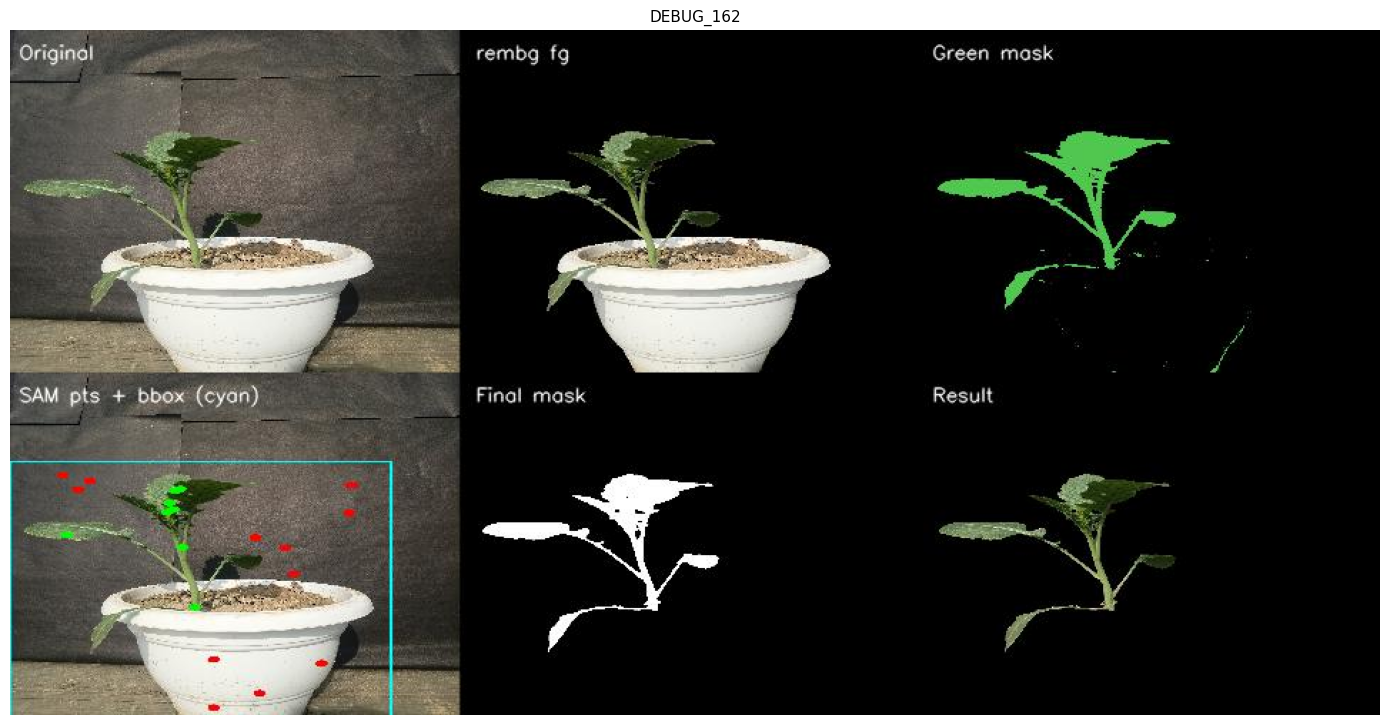

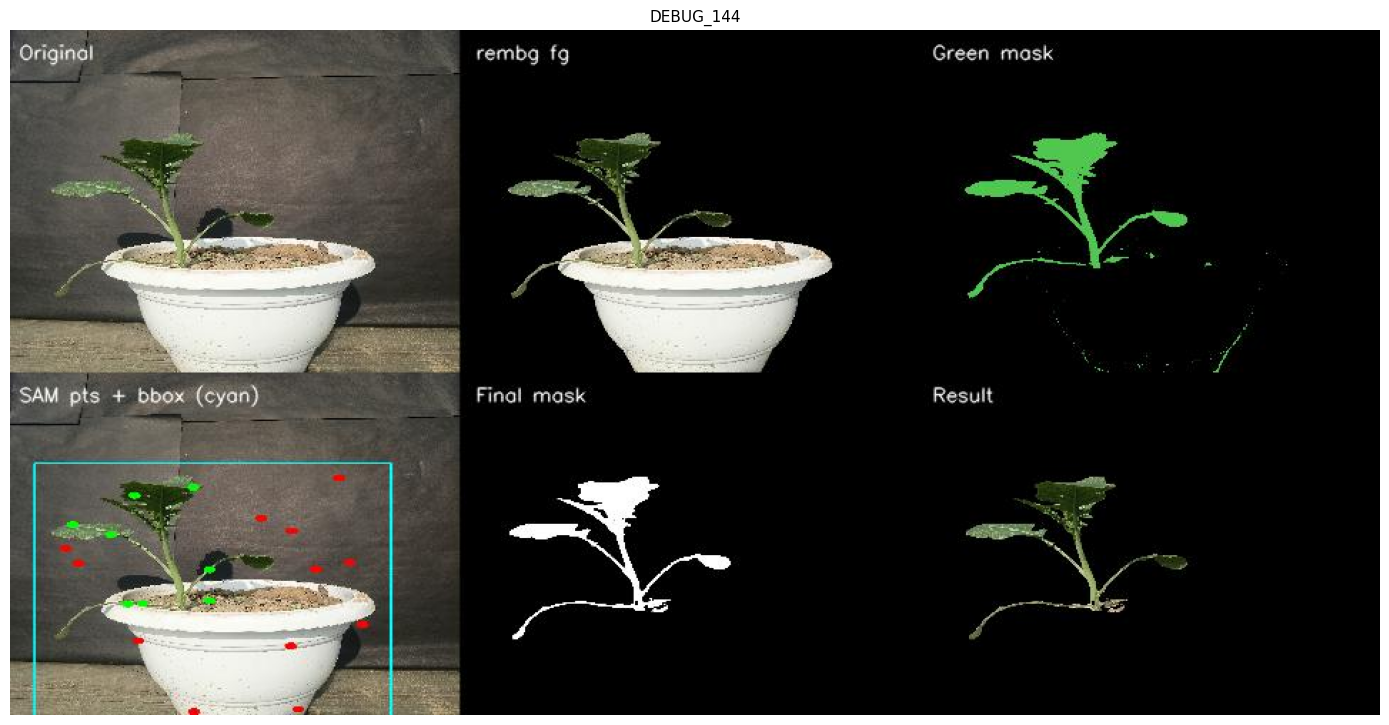

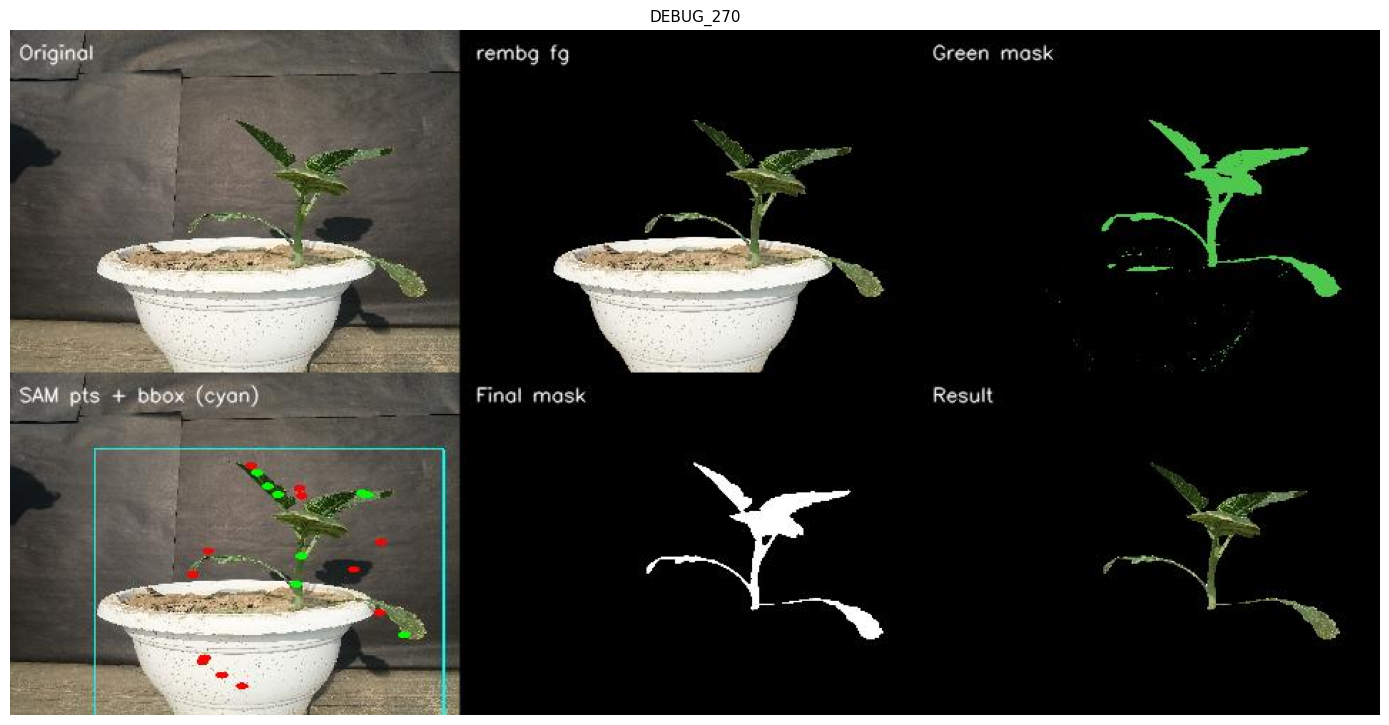

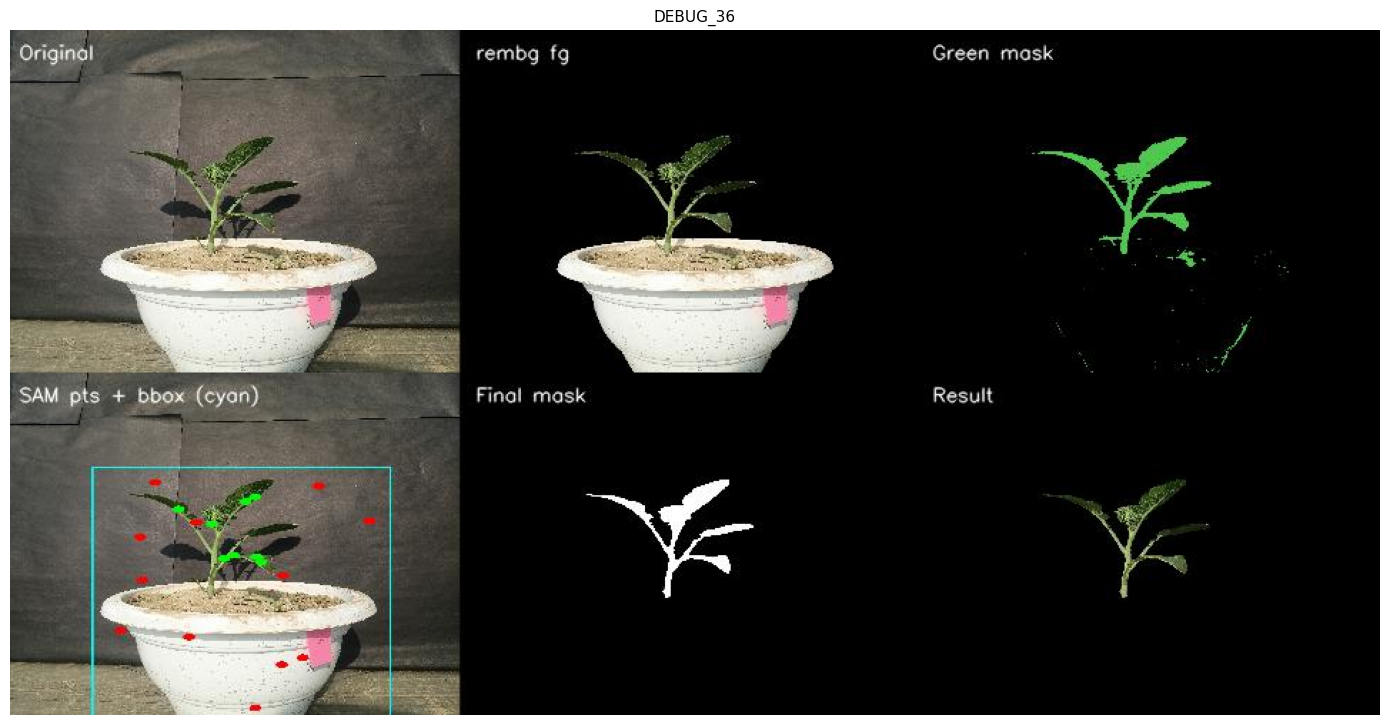

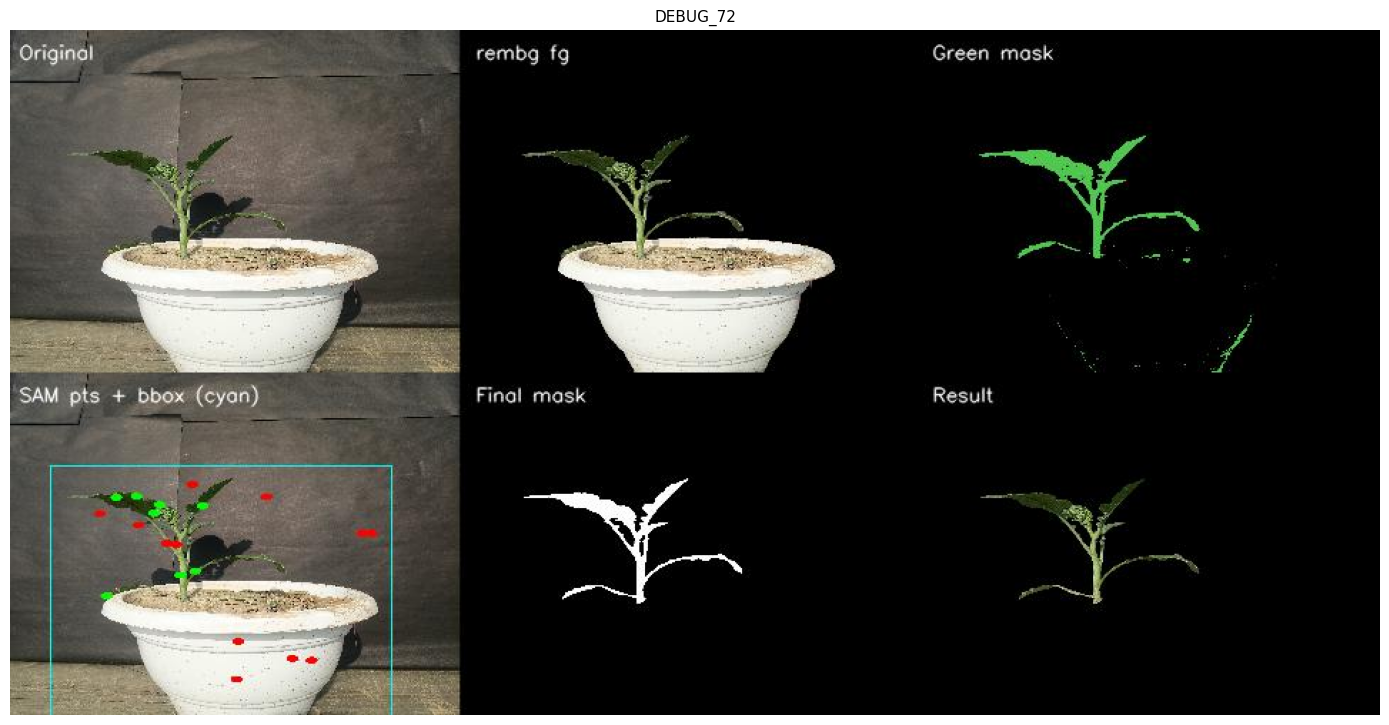

In [18]:
debug_files = sorted(Path(DEBUG_DIR).glob("DEBUG_*.jpg"))

if not debug_files:
    print("No debug mosaics found. Set SAVE_DEBUG = True and re-run.")
else:
    sample_dbg = random.sample(debug_files, min(5, len(debug_files)))
    for dbg in sample_dbg:
        img = np.array(Image.open(dbg))
        plt.figure(figsize=(14, 9))
        plt.imshow(img)
        plt.title(dbg.stem, fontsize=11)
        plt.axis("off")
        plt.tight_layout()
        plt.show()


In [19]:
print(f"\nResizing all {cfg.rotation.num_images} images to {cfg.camera.resized_w}x{cfg.camera.resized_h}...")
for image_name in views_key():
    fname = f'{image_name}.png'
    img   = cv2.imread(str(SEGMENTED_DIR / fname))
    if img is None: print(f'  Cannot read {fname}'); continue
    cv2.imwrite(str(RESIZED_DIR / fname),
                cv2.resize(img, (cfg.camera.resized_w, cfg.camera.resized_h), interpolation=cv2.INTER_AREA))
print('Resize done.')


Resizing all 20 images to 400x533...
Resize done.


<div style="width: 100%;">
  <h3><tt>Silhouette extraction</tt></h3>
  <hr style="border: 1px solid #ccc; width: 100%; margin: 0;">
  <p><i>Using MEAN centroid across all views. Per-image centroid tracks leaf mass distribution which changes with rotation — causing over-correction and inconsistent views.Mean centroid cancels out leaf asymmetry and estimates the true turntable rotation axis.</i></p>
  <hr style="border: 1px solid #ccc; width: 100%; margin: 0;">
</div>

Extracting silhouettes (simple threshold)...
                View    Plant px
----------------------------------
               0.png       5,905
             108.png       6,732
             126.png       7,535
             144.png       8,023
             162.png       9,645
              18.png       4,986
             180.png      11,030
             198.png      11,630
             216.png      12,279
             234.png      11,854
             252.png       8,911
             270.png       7,474
             288.png       8,083
             306.png       8,469
             324.png       8,076
             342.png       5,822
              36.png       4,575
              54.png       5,022
              72.png       5,056
              90.png       5,621

Done.


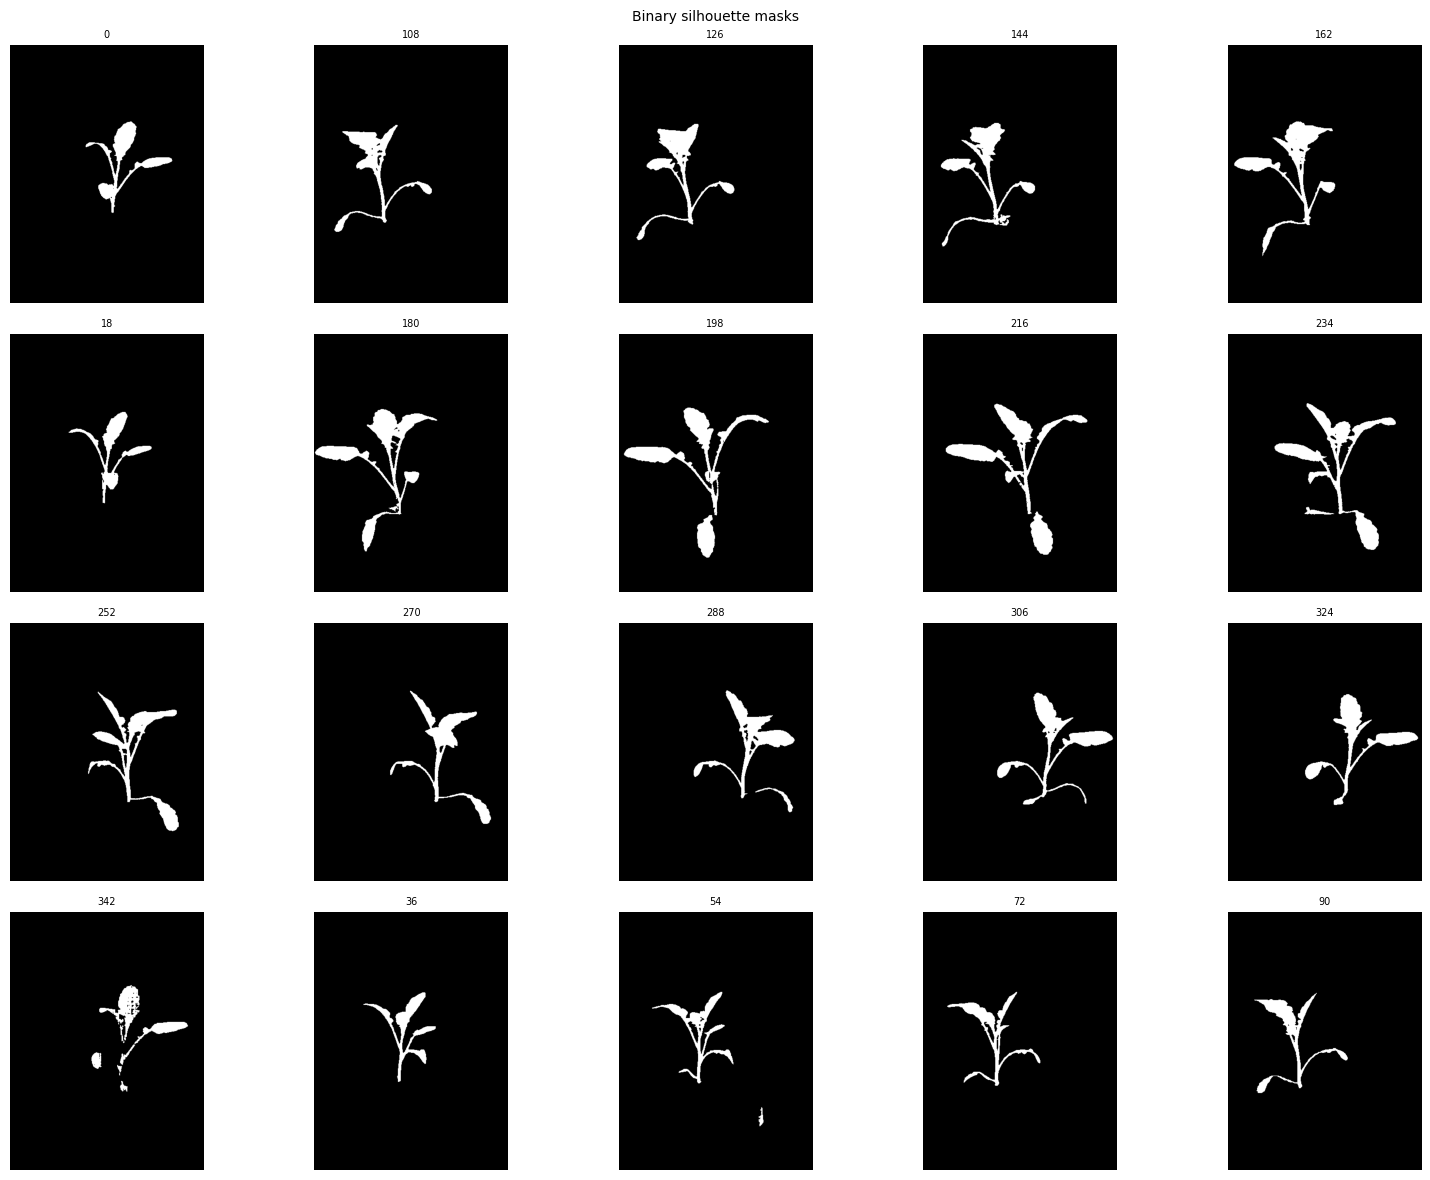

In [20]:
image_paths = sorted(RESIZED_DIR.glob("*.png"))

print('Extracting silhouettes (simple threshold)...')
print(f'{"View":>20}  {"Plant px":>10}')
print('-' * 34)

for path in image_paths:
    mask = extract_silhouette(image_path=path)

    fname = path.name

    # Save
    cv2.imwrite(str(MASK_DIR / fname), mask)

    # Overlay
    img_vis = cv2.imread(str(path))
    overlay = img_vis.copy()
    overlay[mask > 0] = (0, 200, 0)

    cv2.imwrite(
        str(MASK_VIS_DIR / fname),
        cv2.addWeighted(img_vis, 0.5, overlay, 0.5, 0)
    )

    plant_px = int((mask > 0).sum())
    print(f'{fname:>20}  {plant_px:>10,}')

print('\nDone.')

n_cols = 5
n_rows = math.ceil(len(image_paths) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = np.array(axes).reshape(n_rows, n_cols)

for idx, path in enumerate(image_paths):
    r, c = divmod(idx, n_cols)
    fname = path.name

    mask_raw = cv2.imread(str(MASK_DIR / fname), cv2.IMREAD_GRAYSCALE)
    axes[r][c].imshow(mask_raw, cmap='gray')
    axes[r][c].set_title(path.stem, fontsize=7)
    axes[r][c].axis('off')

for idx in range(len(image_paths), n_rows * n_cols):
    r, c = divmod(idx, n_cols)
    axes[r][c].axis('off')

plt.suptitle('Binary silhouette masks', fontsize=10)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'silhouettes_binary.png'), dpi=150)
plt.show()


<div style="width: 100%;">
  <h3><tt>Pseudo label generation using SAM</tt></h3>
  <!-- <hr style="border: 1px solid #ccc; width: 100%; margin: 0;"> -->
  <p><i></i></p>
  <!-- <hr style="border: 1px solid #ccc; width: 100%; margin: 0;"> -->
</div>

In [21]:
image_names = views_name()
print(image_names)

['0.png', '18.png', '36.png', '54.png', '72.png', '90.png', '108.png', '126.png', '144.png', '162.png', '180.png', '198.png', '216.png', '234.png', '252.png', '270.png', '288.png', '306.png', '324.png', '342.png']


In [22]:
print("Generating pseudo-labels...")
stats = run_pseudo_label_pipeline(
    image_names=image_names,
    resized_path=RESIZED_DIR,
    mask_path=MASK_DIR,
    label_path=LABEL_DIR,
    label_vis_path=LABEL_VIS_DIR,
    cfg=cfg,
    use_sam=True,
    predictor=predictor
    )


Generating pseudo-labels...

PSEUDO-LABEL GENERATION
  SAM:  Yes (point-prompted)



Pseudo-labels: 100%|██████████| 20/20 [00:42<00:00,  2.12s/it]


Done in 0.7 min

 view        bg     leaf    stem      pet    apex
--------------------------------------------------
 0.png   207,295    3,466     438    1,888     113
 18.png   208,214    2,534      28    2,311     113
 36.png   208,625    2,287     394    1,781     113
 54.png   208,178    1,791     189    2,937     105
 72.png   208,144    2,045     565    2,333     113
 90.png   207,579    2,837     501    2,170     113
 108.png   206,468    3,411     570    2,638     113
 126.png   205,665    3,936     626    2,860     113
 144.png   205,177    4,010     547    3,353     113
 162.png   203,555    5,520     812    3,207     106
 180.png   202,170    6,351      72    4,494     113
 198.png   201,570    7,319      34    4,164     113
 216.png   200,921    7,811       0    4,355     113
 234.png   201,346    6,898       0    4,956       0
 252.png   204,289    4,815     485    3,500     111
 270.png   205,726    4,231     594    2,536     113
 288.png   205,117    4,392       0    3

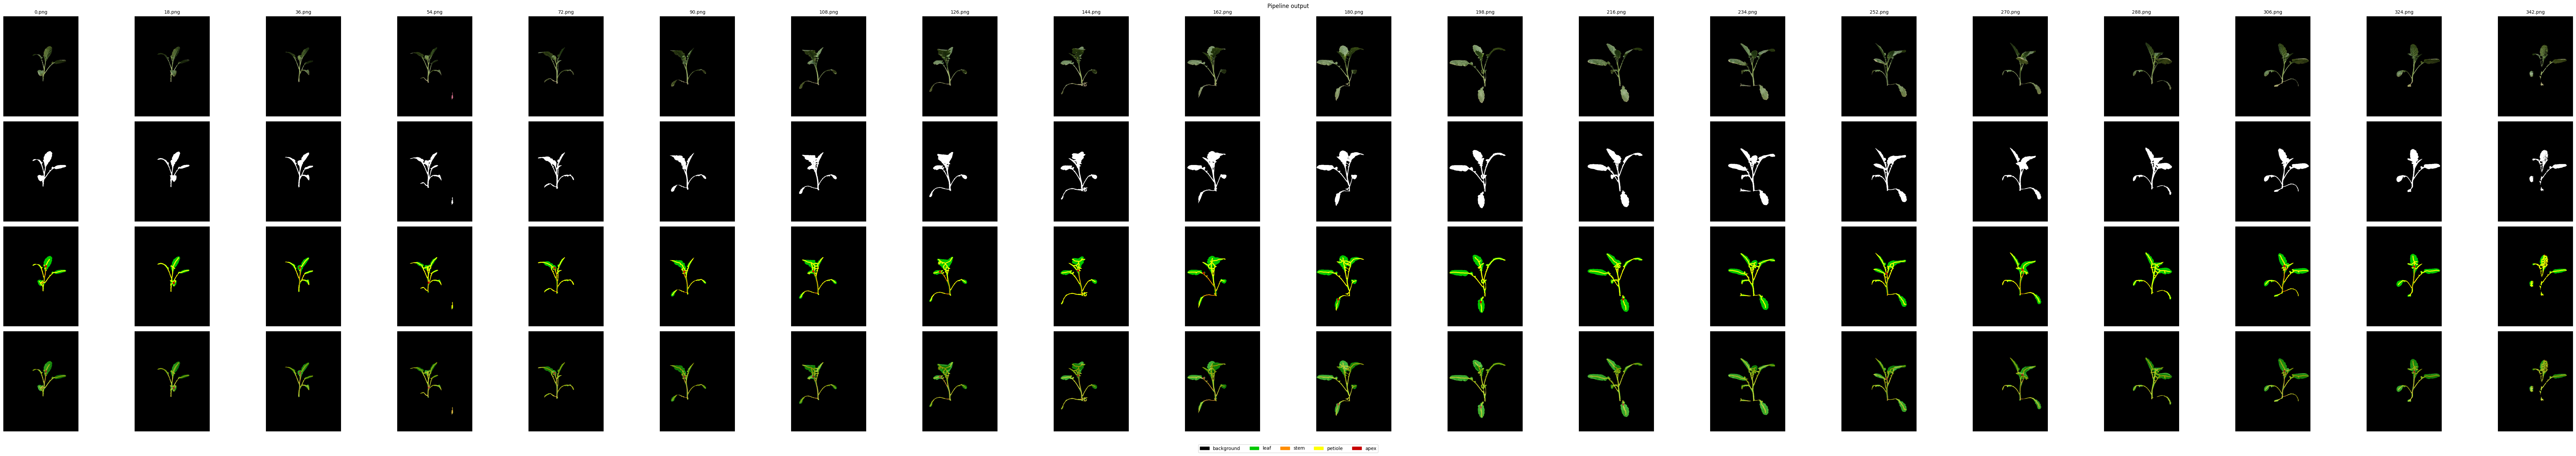

Saved → /content/plant_nerf/checkpoints/pipeline_output.png


In [23]:
visualize_pipeline_output(
    image_names=image_names,
    resized_path=RESIZED_DIR,
    mask_path=MASK_DIR,
    label_path=LABEL_DIR,
    checkpoint_path=CKPT_DIR,
    cfg=cfg,
    )

In [24]:
visualize_top_view(resized_path=RESIZED_DIR, mask_path=MASK_DIR, label_path=LABEL_DIR, checkpoint_path=CKPT_DIR, cfg=cfg)

Top image not found.


<div style="width: 100%;">
  <h3><tt>Camera poses for NeRF</tt></h3>
  <!-- <hr style="border: 1px solid #ccc; width: 100%; margin: 0;"> -->
  <p><i></i></p>
  <!-- <hr style="border: 1px solid #ccc; width: 100%; margin: 0;"> -->
</div>

In [25]:
plant_target = np.array([0,0,0])
poses = build_initial_poses(image_names=image_names, plant_target=plant_target, cfg=cfg)

In [26]:
def save_transforms_json(poses_dict, out_path):
    frames = []
    for image_name in image_names:
        view_key = image_name.split('.')[0]
        if view_key not in poses_dict:
            continue
        frames.append({
            'file_path': f'images_resized/{image_name}',
            'transform_matrix': poses_dict[view_key].tolist()
        })

    transform_data = {
                          'camera_model': 'OPENCV',
                          **cfg.camera.nerf_intrinsics,
                          'k1': 0.0, 'k2': 0.0, 'p1': 0.0, 'p2': 0.0,
                          'frames': frames
                      }

    with open(out_path, 'w') as f:
        json.dump(transform_data, f, indent=2)

print('Pose verification — plant_target projected position per view:')
print(f'  {"View":>8}  {"proj_x":>8}  {"proj_y":>8}  {"offset_from_centre":>20}')
for image_name in image_names:
    if image_name == 'top.png':
        continue

    rotation_angle = image_name.split('.')[0]

    P = poses[rotation_angle]
    R33 = P[:3, :3]
    t = P[:3, 3]
    cam_pos = plant_target - t
    cam_coord = R33.T @ cam_pos
    if cam_coord[2] != 0:
        px_proj = (-cam_coord[0] / cam_coord[2]) * cfg.camera.focal_length + cfg.camera.resized_w / 2
        py_proj = (-cam_coord[1] / cam_coord[2]) * cfg.camera.focal_length + cfg.camera.resized_h / 2
    else:
        px_proj = py_proj = cfg.camera.resized_w / 2
    off = math.hypot(px_proj - cfg.camera.resized_w/2, py_proj - cfg.camera.resized_h/2)
    print(f'  {str(rotation_angle):>8}  {px_proj:>8.1f}  {py_proj:>8.1f}  {off:>8.2f} px from centre')

save_transforms_json(poses, BASE_DIR / 'transforms.json')

print(f'\\nPoses done. focal={cfg.camera.focal_length:.1f}px')
print(f'Camera target: [{plant_target[0]:+.4f}, {plant_target[1]:+.4f}, {plant_target[2]:+.4f}]')
print(f'Top view enabled: {"yes" if "top.png" in image_names else "no"}')

Pose verification — plant_target projected position per view:
      View    proj_x    proj_y    offset_from_centre
         0     200.0     266.5      0.00 px from centre
        18     200.0     266.5      0.00 px from centre
        36     200.0     266.5      0.00 px from centre
        54     200.0     266.5      0.00 px from centre
        72     200.0     266.5      0.00 px from centre
        90     200.0     266.5      0.00 px from centre
       108     200.0     266.5      0.00 px from centre
       126     200.0     266.5      0.00 px from centre
       144     200.0     266.5      0.00 px from centre
       162     200.0     266.5      0.00 px from centre
       180     200.0     266.5      0.00 px from centre
       198     200.0     266.5      0.00 px from centre
       216     200.0     266.5      0.00 px from centre
       234     200.0     266.5      0.00 px from centre
       252     200.0     266.5      0.00 px from centre
       270     200.0     266.5      0.00 px f

<div style="width: 100%;">
  <h3><tt>Neural Radiance field Model</tt></h3>
</div>

In [27]:
n_params = sum(p.numel() for p in SemanticNeRF(plant_bound=cfg.plant_bound, num_classes=cfg.semantic.num_classes).parameters())
print(f'SemanticNeRF ready. Parameters: {n_params:,}')
print('Hash encoding bugs FIXED: abs() hash + precomputed corners + input clamp')

SemanticNeRF ready. Parameters: 33,631,177
Hash encoding bugs FIXED: abs() hash + precomputed corners + input clamp


In [28]:
print("Poses keys:", poses.keys())
print("Available view keys:", image_names)

Poses keys: dict_keys(['0', '18', '36', '54', '72', '90', '108', '126', '144', '162', '180', '198', '216', '234', '252', '270', '288', '306', '324', '342'])
Available view keys: ['0.png', '18.png', '36.png', '54.png', '72.png', '90.png', '108.png', '126.png', '144.png', '162.png', '180.png', '198.png', '216.png', '234.png', '252.png', '270.png', '288.png', '306.png', '324.png', '342.png']


In [29]:
dataset = PlantDataset(image_names=image_names, poses=poses, label_path=LABEL_DIR, mask_path=MASK_DIR, resized_path=RESIZED_DIR, cfg=cfg)

print(f'Phase 1 Dataset ready  ({len(image_names)} side views only).')
print(f'  Rays/batch    : {cfg.training.batch_rays:,}')
if 'top.png' in image_names:
    print(f'  Top view will be introduced at step {cfg.loss.top_view_start_iter}')
else:
    print('  ⚠️  No top view found — running side-views-only pipeline')

Loading dataset (20 views)...


100%|██████████| 20/20 [00:00<00:00, 37.32it/s]


  Total rays :    4,264,000
  Plant rays :      156,728  (3.7%)
  BG rays    :    4,107,272  (96.3%)
  Sampling   : 75% plant / 25% background per batch
Phase 1 Dataset ready  (20 side views only).
  Rays/batch    : 4,096
  ⚠️  No top view found — running side-views-only pipeline


<div style="width: 100%;">
  <h3><tt>Training</tt></h3>
</div>

In [30]:
vars_to_delete = ['session', 'predictor', 'img', 'hsv', 'rough', 'P', 'cam_coord']

for var_name in vars_to_delete:
    if var_name in globals():
        del globals()[var_name]
        print(f"Deleted: {var_name}")

gc.collect()
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print('═' * 40)
print("Memory Sweep Complete. Current VRAM:")
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"Reserved:  {torch.cuda.memory_reserved() / 1024**3:.2f} GB")
print('═' * 40)

Deleted: session
Deleted: predictor
Deleted: img
Deleted: P
Deleted: cam_coord
════════════════════════════════════════
Memory Sweep Complete. Current VRAM:
Allocated: 0.01 GB
Reserved:  0.02 GB
════════════════════════════════════════


In [31]:
early_stop_config = EarlyStopConfig()
early_stopper     = EarlyStopper(early_stop_config)

view_keys = [k.split('.')[0] for k in image_names]

model        = SemanticNeRF(plant_bound=cfg.plant_bound, num_classes=cfg.semantic.num_classes).to(cfg.device)
model        = torch.compile(model)
pose_refiner = PoseRefiner(base_poses=poses, views=view_keys).to(cfg.device)

optimizer = torch.optim.Adam([
    {'params': model.parameters(),        'lr': cfg.training.lr},
    {'params': pose_refiner.parameters(), 'lr': cfg.training.pose_lr},
])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=cfg.training.num_iters, eta_min=cfg.training.lr * 0.01)
scaler = torch.amp.GradScaler('cuda', enabled=cfg.training.use_amp)

history = {k: [] for k in
           ['total', 'color', 'silhouette', 'semantic',
            'distortion', 'bg_acc', 'pose', 'top_pose']}   # top_pose added
early_stopped        = False
stop_condition_met_at = None

step    = 0
pbar    = tqdm(total=cfg.training.num_iters, desc='Training')

while step < cfg.training.num_iters:
    # INTRODCUTION OF TOP VIEW
    if step == cfg.training.top_view_start_iter and cfg.rotation.use_top_view:

        print(f'\n{"═"*60}')
        print(f'Step {step}: PHASE 2 — Top view introduced + top-view pose refinement ON')
        print(f'{"═"*60}')

        dataset = PlantDataset(view_keys=view_keys)
        print(f'  Dataset rebuilt: {len(view_keys)} views (side + top)')


    rays_o_base, rays_d_base, view_ids, gt_rgb, gt_mask, gt_sem = dataset.get_batch(
        cfg.training.batch_rays,
        device=cfg.device
    )
    bg_mask = (gt_mask.squeeze() < 0.5)

    model.update_step(step)

    if step >= cfg.training.pose_start_iter:
        rays_o, rays_d = pose_refiner.transform_rays(
            rays_o_base, rays_d_base, view_ids)

    elif step >= cfg.training.top_view_start_iter and pose_refiner.top_view_exists:
        top_global_id = pose_refiner.key_to_idx['top']
        is_top_ray    = (view_ids == top_global_id)
        if is_top_ray.any():
            rays_o = rays_o_base.clone()
            rays_d = rays_d_base.clone()
            top_ro, top_rd = pose_refiner.transform_rays(
                rays_o_base[is_top_ray],
                rays_d_base[is_top_ray],
                view_ids[is_top_ray],
            )
            rays_o[is_top_ray] = top_ro
            rays_d[is_top_ray] = top_rd
        else:
            rays_o, rays_d = rays_o_base, rays_d_base

    else:
        rays_o, rays_d = rays_o_base, rays_d_base

    with torch.amp.autocast('cuda', enabled=cfg.training.use_amp):
        pts_c, z_c = sample_coarse(
            rays_o, rays_d, cfg.training.near, cfg.training.far,
            cfg.training.n_samples_coarse)
        N, S, _ = pts_c.shape
        dc, cc, sc = model(
            pts_c.reshape(-1, 3),
            rays_d.unsqueeze(1).expand(N, S, 3).reshape(-1, 3))
        rgb_c, acc_c, sem_c, _, wc = volume_render(
            dc.reshape(N, S, 1), cc.reshape(N, S, 3),
            sc.reshape(N, S, cfg.semantic.num_classes), z_c, rays_d)

        pts_f, z_f = sample_fine(rays_o, rays_d, z_c, wc.detach(),
                                 cfg.training.n_samples_fine)
        N, S2, _ = pts_f.shape
        df, cf, sf = model(
            pts_f.reshape(-1, 3),
            rays_d.unsqueeze(1).expand(N, S2, 3).reshape(-1, 3))
        rgb_f, acc_f, sem_f, _, wf = volume_render(
            df.reshape(N, S2, 1), cf.reshape(N, S2, 3),
            sf.reshape(N, S2, cfg.semantic.num_classes), z_f, rays_d)

        preds = {'rgb_f': rgb_f, 'rgb_c': rgb_c,
                 'acc_f': acc_f, 'acc_c': acc_c,
                 'sem_f': sem_f, 'sem_c': sem_c,
                 'wf': wf, 'z_f': z_f, 'wc': wc, 'z_c': z_c}
        gts_d = {'rgb': gt_rgb, 'mask': gt_mask, 'sem': gt_sem}

        loss, loss_log = compute_total_loss(preds, gts_d, step, cfg, pose_refiner)

    optimizer.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)

    if step >= cfg.training.top_view_start_iter and pose_refiner.top_view_exists:
        torch.nn.utils.clip_grad_norm_(pose_refiner.parameters(), max_norm=0.1)
    elif step >= cfg.training.pose_start_iter:
        torch.nn.utils.clip_grad_norm_(pose_refiner.parameters(), max_norm=0.1)

    scaler.step(optimizer)
    scaler.update()
    scheduler.step()

    for k in history.keys():
        history[k].append(loss_log.get(k, 0.0))

    if step % cfg.training.log_every == 0:
        with torch.no_grad():
            plant_acc_log = acc_f[~bg_mask].mean().item() if (~bg_mask).any() else 0.0
            bg_acc_log    = acc_f[ bg_mask].mean().item() if   bg_mask.any() else 0.0
            psnr_log      = -10 * math.log10(F.mse_loss(rgb_f, gt_rgb).item() + 1e-8)

        print(
            f'Step {step:5d}: loss={loss_log["total"]:.4f} | '
            f'color={loss_log["color"]:.4f}  sil={loss_log["silhouette"]:.4f}  '
            f'sem={loss_log["semantic_w"]:.4f}  dist={loss_log["distortion"]:.4f}  '
            f'bg_acc={bg_acc_log:.3f}  plant_acc={plant_acc_log:.3f}  '
            f'psnr={psnr_log:.1f}dB  '
            f'pose={loss_log["pose_w"]:.5f}  '
            f'top_pose={loss_log["top_pose_w"]:.5f}'    # NEW
        )

        with torch.no_grad():
            max_rot   = pose_refiner.delta_rot.abs().max().item()
            max_trans = pose_refiner.delta_trans.abs().max().item()
            print(f'         > Camera Delta: Rot_max={max_rot:.6f} rad | Trans_max={max_trans:.6f} units')

        if step >= early_stop_config.min_iters:
            with torch.no_grad():
                plant_acc_est = acc_f[~bg_mask].mean().item() if (~bg_mask).any() else 0.0
                bg_acc_est    = acc_f[ bg_mask].mean().item() if   bg_mask.any() else 1.0
                psnr_est      = -10 * math.log10(F.mse_loss(rgb_f, gt_rgb).item() + 1e-8)

            if early_stopper.step(step, plant_acc_est, bg_acc_est, psnr_est):
                print(f'\nEarly stopping triggered at step {step}')
                break

    step += 1
    pbar.update(1)

pbar.close()

Training:   0%|          | 1/4000 [01:31<101:43:41, 91.58s/it]

Step     0: loss=9.4684 | color=0.1038  sil=4.6945  sem=0.0000  dist=0.0028  bg_acc=0.049  plant_acc=0.046  psnr=10.3dB  pose=0.00000  top_pose=0.00000
         > Camera Delta: Rot_max=0.000002 rad | Trans_max=0.000003 units


Training:   5%|▌         | 201/4000 [02:18<14:56,  4.24it/s]

Step   200: loss=2.5744 | color=0.0349  sil=1.1320  sem=0.0000  dist=0.3398  bg_acc=0.264  plant_acc=0.733  psnr=15.0dB  pose=0.00000  top_pose=0.00000
         > Camera Delta: Rot_max=0.000002 rad | Trans_max=0.000003 units


Training:  10%|█         | 401/4000 [03:04<13:51,  4.33it/s]

...

Training:  90%|█████████ | 3601/4000 [14:57<01:29,  4.45it/s]

Step  3600: loss=0.4285 | color=0.0190  sil=0.3866  sem=0.0000  dist=0.1149  bg_acc=0.064  plant_acc=0.922  psnr=17.7dB  pose=0.00000  top_pose=0.00000
         > Camera Delta: Rot_max=0.000002 rad | Trans_max=0.000003 units


Training:  95%|█████████▌| 3801/4000 [15:42<00:45,  4.41it/s]

Step  3800: loss=0.4498 | color=0.0198  sil=0.4039  sem=0.0000  dist=0.1137  bg_acc=0.069  plant_acc=0.921  psnr=17.5dB  pose=0.00000  top_pose=0.00000
         > Camera Delta: Rot_max=0.000002 rad | Trans_max=0.000003 units


Training: 100%|██████████| 4000/4000 [16:26<00:00,  4.05it/s]


In [32]:
poses = pose_refiner.export_pose_dict()
save_transforms_json(poses, BASE_DIR / 'transforms.json')

view_keys = [k.split('.')[0] for k in image_names]

with torch.no_grad():
    print('\nPose deltas after training:')
    for view_key in view_keys:
        idx = pose_refiner.key_to_idx[view_key]
        rot_deg = torch.linalg.norm(pose_refiner.delta_rot[idx]).item() * 180.0 / math.pi
        trans_mag = torch.linalg.norm(pose_refiner.delta_trans[idx]).item()
        print(f'  {str(view_key):>8}: rot≈{rot_deg:6.2f}°  trans≈{trans_mag:7.4f}')


Pose deltas after training:
         0: rot≈  0.00°  trans≈ 0.0000
        18: rot≈  0.00°  trans≈ 0.0000
        36: rot≈  0.00°  trans≈ 0.0000
        54: rot≈  0.00°  trans≈ 0.0000
        72: rot≈  0.00°  trans≈ 0.0000
        90: rot≈  0.00°  trans≈ 0.0000
       108: rot≈  0.00°  trans≈ 0.0000
       126: rot≈  0.00°  trans≈ 0.0000
       144: rot≈  0.00°  trans≈ 0.0000
       162: rot≈  0.00°  trans≈ 0.0000
       180: rot≈  0.00°  trans≈ 0.0000
       198: rot≈  0.00°  trans≈ 0.0000
       216: rot≈  0.00°  trans≈ 0.0000
       234: rot≈  0.00°  trans≈ 0.0000
       252: rot≈  0.00°  trans≈ 0.0000
       270: rot≈  0.00°  trans≈ 0.0000
       288: rot≈  0.00°  trans≈ 0.0000
       306: rot≈  0.00°  trans≈ 0.0000
       324: rot≈  0.00°  trans≈ 0.0000
       342: rot≈  0.00°  trans≈ 0.0000


<div style="width: 100%;">
  <h3><tt>Rendering the results</tt></h3>
</div>

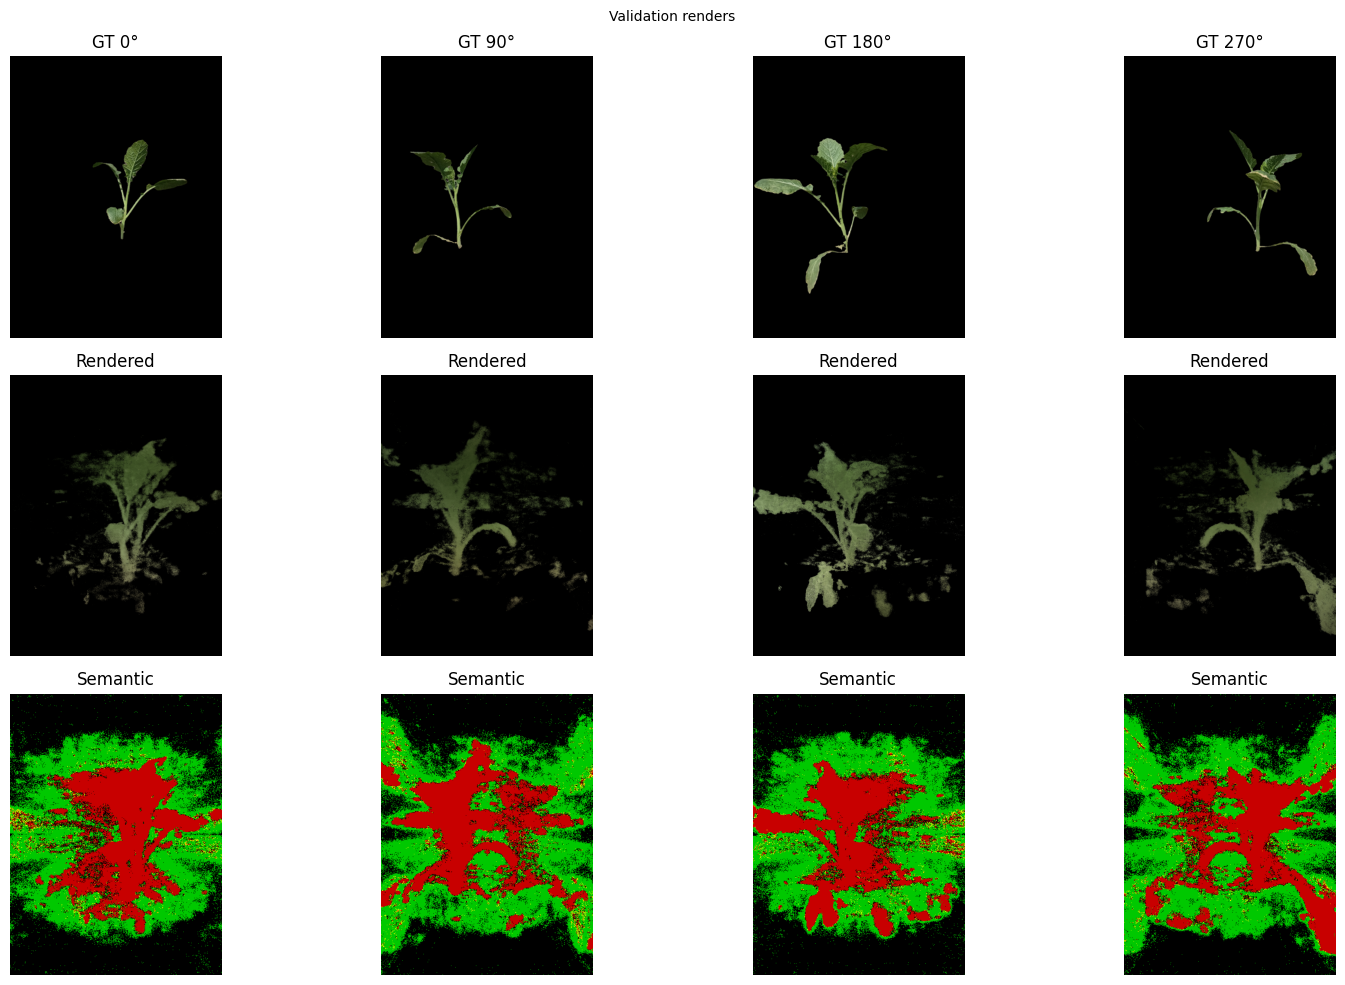

In [33]:
from src.models.arch import get_rays
model.eval()

def render_image(model, pose, H, W, focal, chunk=1024):
    pose_t=torch.tensor(pose,dtype=torch.float32,device=cfg.device)
    ro,rd=get_rays(H,W,focal,pose_t)
    ro_f=ro.reshape(-1,3); rd_f=rd.reshape(-1,3); N=ro_f.shape[0]
    rgbs,accs,sems=[],[],[]
    with torch.no_grad():
        for s in range(0,N,chunk):
            e=min(s+chunk,N); r_o=ro_f[s:e]; r_d=rd_f[s:e]
            pts_c,z_c=sample_coarse(r_o,r_d,cfg.training.near,cfg.training.far,cfg.training.n_samples_coarse)
            n,sc,_=pts_c.shape
            dc,cc,sc2=model(pts_c.reshape(-1,3),r_d.unsqueeze(1).expand(n,sc,3).reshape(-1,3))
            dc=dc.reshape(n,sc,1);cc=cc.reshape(n,sc,3);sc2=sc2.reshape(n,sc,cfg.semantic.num_classes)
            _,_,_,_,wc=volume_render(dc,cc,sc2,z_c,r_d)
            pts_f,z_f=sample_fine(r_o,r_d,z_c,wc,cfg.training.n_samples_fine)
            n,sf,_=pts_f.shape
            df,cf,sf2=model(pts_f.reshape(-1,3),r_d.unsqueeze(1).expand(n,sf,3).reshape(-1,3))
            df=df.reshape(n,sf,1);cf=cf.reshape(n,sf,3);sf2=sf2.reshape(n,sf,cfg.semantic.num_classes)
            rgb,acc,sem,_,_=volume_render(df,cf,sf2,z_f,r_d)
            rgbs.append(rgb.cpu());accs.append(acc.cpu());sems.append(sem.cpu())
    rgb_img=torch.cat(rgbs).reshape(H,W,3).numpy()
    sem_cls=torch.cat(sems).reshape(H,W,cfg.semantic.num_classes).argmax(-1).numpy().astype(np.uint8)
    return rgb_img, sem_cls

# Render 4 test views
fig,axes=plt.subplots(3,4,figsize=(16,10))
for col,angle in enumerate([0,90,180,270]):
    fname=f'{angle}.png'
    gt=cv2.cvtColor(cv2.imread(str(RESIZED_DIR/fname)),cv2.COLOR_BGR2RGB)
    rgb_p,sem_p=render_image(model,poses[str(angle)],cfg.camera.resized_h,cfg.camera.resized_w,cfg.camera.focal_length)
    sem_c=np.zeros((*sem_p.shape,3),dtype=np.uint8)
    for cid,bgr in cfg.semantic.class_colors_bgr.items(): sem_c[sem_p==cid]=bgr[::-1]
    axes[0][col].imshow(gt);              axes[0][col].set_title(f'GT {angle}°')
    axes[1][col].imshow(rgb_p.clip(0,1)); axes[1][col].set_title('Rendered')
    axes[2][col].imshow(sem_c);           axes[2][col].set_title('Semantic')
    for r in range(3): axes[r][col].axis('off')
plt.suptitle('Validation renders',fontsize=10)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR/'validation_renders.png'),dpi=150)
plt.show()

In [34]:
def render_image(model, pose, H, W, focal, chunk=1024):
    pose_t = torch.tensor(pose, dtype=torch.float32, device=cfg.device)
    ro, rd = get_rays(H, W, focal, pose_t)
    ro_f = ro.reshape(-1, 3)
    rd_f = rd.reshape(-1, 3)
    N = ro_f.shape[0]

    rgbs, accs = [], []

    with torch.no_grad():
        for s in range(0, N, chunk):
            e = min(s + chunk, N)
            r_o = ro_f[s:e]
            r_d = rd_f[s:e]

            pts_c, z_c = sample_coarse(
                r_o, r_d,
                cfg.training.near,
                cfg.training.far,
                cfg.training.n_samples_coarse
            )

            n, sc, _ = pts_c.shape
            dc, cc, sc2 = model(
                pts_c.reshape(-1, 3),
                r_d.unsqueeze(1).expand(n, sc, 3).reshape(-1, 3)
            )

            dc = dc.reshape(n, sc, 1)
            cc = cc.reshape(n, sc, 3)
            sc2 = sc2.reshape(n, sc, cfg.semantic.num_classes)

            _, _, _, _, wc = volume_render(dc, cc, sc2, z_c, r_d)

            pts_f, z_f = sample_fine(
                r_o, r_d, z_c, wc,
                cfg.training.n_samples_fine
            )

            n, sf, _ = pts_f.shape
            df, cf, sf2 = model(
                pts_f.reshape(-1, 3),
                r_d.unsqueeze(1).expand(n, sf, 3).reshape(-1, 3)
            )

            df = df.reshape(n, sf, 1)
            cf = cf.reshape(n, sf, 3)
            sf2 = sf2.reshape(n, sf, cfg.semantic.num_classes)

            rgb, acc, _, _, _ = volume_render(df, cf, sf2, z_f, r_d)

            rgbs.append(rgb.cpu())
            accs.append(acc.cpu())

    rgb_img = torch.cat(rgbs).reshape(H, W, 3).numpy()
    acc_img = torch.cat(accs).reshape(H, W).numpy()

    return rgb_img, acc_img

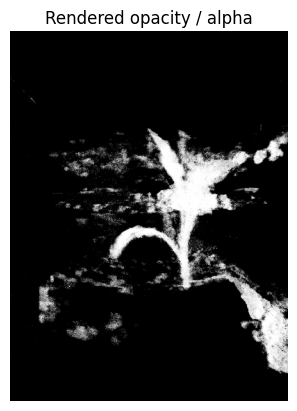

In [35]:
rgb_p, acc_p = render_image(
    model,
    poses[str(angle)],
    cfg.camera.resized_h,
    cfg.camera.resized_w,
    cfg.camera.focal_length
)

plt.imshow(acc_p, cmap="gray", vmin=0, vmax=1)
plt.title("Rendered opacity / alpha")
plt.axis("off")
plt.show()

In [ ]:
# PSNR all views
psnrs=[]
for angle in cfg.rotation.rotation_angles:
    gt=cv2.cvtColor(cv2.imread(str(RESIZED_DIR/f'{angle}.png')),
                    cv2.COLOR_BGR2RGB).astype(np.float32)/255.
    rgb_p,_=render_image(model,poses[str(angle)],cfg.camera.resized_h,cfg.camera.resized_w,cfg.camera.focal_length)
    psnr=-10*np.log10(np.mean((gt-rgb_p.clip(0,1))**2)+1e-8)
    psnrs.append(psnr)
    print(f'  {angle:3d}°  PSNR={psnr:.2f} dB')
print(f'\nMean PSNR: {np.mean(psnrs):.2f} dB')

    0°  PSNR=19.77 dB
   18°  PSNR=18.97 dB
   36°  PSNR=17.30 dB
   54°  PSNR=17.16 dB
   72°  PSNR=17.47 dB
   90°  PSNR=18.01 dB
  108°  PSNR=18.12 dB
  126°  PSNR=18.44 dB
  144°  PSNR=19.09 dB
  162°  PSNR=19.21 dB
  180°  PSNR=19.19 dB
  198°  PSNR=19.62 dB
  216°  PSNR=18.99 dB
  234°  PSNR=17.54 dB
  252°  PSNR=16.80 dB
  270°  PSNR=16.24 dB
  288°  PSNR=16.84 dB
  306°  PSNR=17.43 dB
  324°  PSNR=17.49 dB
  342°  PSNR=19.17 dB

Mean PSNR: 18.14 dB


<div style="width: 100%;">
  <h3><tt>Novel view synthesis</tt></h3>
</div>

In [ ]:
from src.models.poses import look_at

def orbit_pose(angle_deg, target=np.zeros(3, dtype=np.float32), radius=None):
    if radius is None:
        radius = cfg.camera.camera_radius

    ar = math.radians(angle_deg)

    eye = target + np.array([
        radius * math.sin(ar),
        0.0,
        radius * math.cos(ar)
    ], dtype=np.float32)

    return look_at(eye, target=target)

pose_novel = orbit_pose(45.0)

rgb_novel, sem_novel = render_image(
    model,
    pose_novel,
    cfg.camera.resized_h,
    cfg.camera.resized_w,
    cfg.camera.focal_length
)

<div style="width: 100%;">
  <h3><tt>Mesh Extraction</tt></h3>
</div>

In [ ]:
# 1. Note the QUOTES! We are passing strings.
# Add any other large variables you used during training here (like 'optimizer', 'loss', etc.)
vars_to_delete = ['session', 'predictor', 'img', 'hsv', 'rough', 'P', 'cam_coord']

for var_name in vars_to_delete:
    if var_name in globals():
        del globals()[var_name]
        print(f"Deleted: {var_name}")

# 2. Aggressive Garbage Collection
gc.collect()
gc.collect()

# 3. Empty the PyTorch Cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect() # Clears out inter-process communication memory

# 4. Prove it worked!
print('═' * 40)
print("Memory Sweep Complete. Current VRAM:")
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"Reserved:  {torch.cuda.memory_reserved() / 1024**3:.2f} GB")
print('═' * 40)

In [ ]:
print('Querying density on 3D voxel grid...')
xs=torch.linspace(-cfg.plant_bound,cfg.plant_bound,cfg.grid_res)
gx,gy,gz=torch.meshgrid(xs,xs,xs,indexing='ij')
pts_flat=torch.stack([gx,gy,gz],-1).reshape(-1,3)
density_vol=np.zeros(cfg.grid_res**3,dtype=np.float32)
sem_vol    =np.zeros(cfg.grid_res**3,dtype=np.uint8)
CHUNK=8192
model.eval()
with torch.no_grad():
    for s in tqdm(range(0,pts_flat.shape[0],CHUNK),desc='Density query'):
        e=min(s+CHUNK,pts_flat.shape[0])
        p=pts_flat[s:e].to(cfg.device); dummy=torch.zeros_like(p)
        den,_,sem=model(p,dummy)
        density_vol[s:e]=den.squeeze(-1).cpu().numpy()
        sem_vol[s:e]=sem.argmax(-1).cpu().numpy().astype(np.uint8)
density_vol=density_vol.reshape(cfg.grid_res,cfg.grid_res,cfg.grid_res)
sem_vol    =sem_vol    .reshape(cfg.grid_res,cfg.grid_res,cfg.grid_res)

del pts_flat, gx, gy, gz, xs
gc.collect()

print(f'Density: min={density_vol.min():.2f} max={density_vol.max():.2f}')

verts,faces,normals,_=measure.marching_cubes(
    density_vol, level=cfg.density_threshold, spacing=(2*cfg.plant_bound/cfg.grid_res,)*3)
verts -= cfg.plant_bound
print(f'Mesh: {len(verts):,} vertices, {len(faces):,} faces')

def w2v(v,b,r): return ((v+b)/(2*b)*(r-1)).clip(0,r-1).astype(int)
vi=w2v(verts[:,0],cfg.plant_bound,cfg.grid_res)
vj=w2v(verts[:,1],cfg.plant_bound,cfg.grid_res)
vk=w2v(verts[:,2],cfg.plant_bound,cfg.grid_res)
vc=sem_vol[vi,vj,vk]
vcol=np.zeros((len(verts),3),dtype=np.float32)
for cid,bgr in cfg.semantic.class_colors_bgr.items():
    vcol[vc==cid]=np.array(bgr[::-1],np.float32)/255.

del density_vol, sem_vol, vi, vj, vk, vc
gc.collect()

obj_path=OUTPUT_DIR/'plant_3d.obj'
with open(obj_path,'w') as f:
    f.write('# Semantic NeRF Plant\n')
    for v,c in zip(verts,vcol): f.write(f'v {v[0]:.6f} {v[1]:.6f} {v[2]:.6f} {c[0]:.4f} {c[1]:.4f} {c[2]:.4f}\n')
    f.write('\n')
    for face in faces: f.write(f'f {face[0]+1} {face[1]+1} {face[2]+1}\n')
print(f'Saved: {obj_path}')

try:
    import open3d as o3d

    print('\nBuilding raw Open3D mesh...')
    o3d_mesh = o3d.geometry.TriangleMesh()
    o3d_mesh.vertices = o3d.utility.Vector3dVector(verts)
    o3d_mesh.triangles = o3d.utility.Vector3iVector(faces)
    o3d_mesh.vertex_colors = o3d.utility.Vector3dVector(vcol)

    del verts, faces, vcol
    gc.collect()

    print('Filtering out floating noise (keeping largest connected component)...')
    triangle_clusters, cluster_n_triangles, cluster_area = o3d_mesh.cluster_connected_triangles()

    triangle_clusters = np.asarray(triangle_clusters)
    cluster_n_triangles = np.asarray(cluster_n_triangles)
    largest_cluster_idx = cluster_n_triangles.argmax()

    triangles_to_remove = triangle_clusters != largest_cluster_idx
    o3d_mesh.remove_triangles_by_mask(triangles_to_remove)
    o3d_mesh.remove_unreferenced_vertices()

    print(f'Cleaned Mesh: {len(o3d_mesh.vertices):,} vertices, {len(o3d_mesh.triangles):,} faces')

    print('Applying Laplacian smoothing...')
    o3d_mesh = o3d_mesh.filter_smooth_laplacian(number_of_iterations=10, lambda_filter=0.5)

    ply_path = str(OUTPUT_DIR / 'plant_3d_clean.ply')
    o3d.io.write_triangle_mesh(ply_path, o3d_mesh)
    print(f'✅ Saved cleaned & smoothed PLY to: {ply_path}')
except Exception as e:
    print(f'Open3D processing failed: {e}. Raw OBJ is still saved.')

<div style="width: 100%;">
  <h3><tt>Mesh Preview</tt></h3>
</div>

In [ ]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
fig=plt.figure(figsize=(12,5))
for idx,(elev,azim) in enumerate([(30,30),(30,120),(30,210)]):
    ax=fig.add_subplot(1,3,idx+1,projection='3d')
    stride=max(1,len(faces)//3000)
    fs=faces[::stride][:3000]
    poly=Poly3DCollection([verts[f] for f in fs],alpha=0.6)
    poly.set_facecolor([[*vcol[f[0]],0.7] for f in fs])
    ax.add_collection3d(poly)
    ax.set_xlim(verts[:,0].min(),verts[:,0].max())
    ax.set_ylim(verts[:,1].min(),verts[:,1].max())
    ax.set_zlim(verts[:,2].min(),verts[:,2].max())
    ax.view_init(elev=elev,azim=azim)
    ax.set_title(f'View {idx+1}',fontsize=9)
handles=[mpatches.Patch(color=np.array(CLASS_COLORS_BGR[c][::-1])/255,label=CLASS_NAMES[c]) for c in CLASS_NAMES]
fig.legend(handles=handles,loc='lower center',ncol=5,fontsize=9)
plt.suptitle('3D Reconstruction — color = semantic class',fontsize=11)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR/'mesh_preview.png'),dpi=150)
plt.show()

<div style="width: 100%;">
  <h3><tt>Post processing</tt></h3>
</div>

In [ ]:
import open3d as o3d
import numpy as np
from scipy.spatial import ConvexHull, cKDTree

class EnhancedGeometricPhenotyper:
    def __init__(self, filepath):
        self.filepath = filepath
        self.pcd = None
        self.stem_pcd = None
        self.leaf_pcd = None
        self.leaf_clusters = []
        np.random.seed(42) # For consistent sampling across runs

    def run_pipeline(self):
        print("[1/4] Loading and Sampling Point Cloud...")
        mesh = o3d.io.read_triangle_mesh(self.filepath)
        self.pcd = mesh.sample_points_uniformly(number_of_points=200000)

        print("[2/4] Segmenting Stem and Leaves...")
        points = np.asarray(self.pcd.points)

        # Robust Center: Median is less sensitive to leaning canopies than Mean
        center_xy = np.median(points[:, :2], axis=0)
        dist_from_center = np.linalg.norm(points[:, :2] - center_xy, axis=1)
        z_min, z_max = np.min(points[:, 2]), np.max(points[:, 2])

        # Stem = inner 6% of the plant's radial width, plus the very bottom base
        is_stem = (dist_from_center < np.percentile(dist_from_center, 6)) | \
                  (points[:, 2] < z_min + (z_max - z_min) * 0.05)

        self.stem_pcd = self.pcd.select_by_index(np.where(is_stem)[0])
        self.leaf_pcd = self.pcd.select_by_index(np.where(~is_stem)[0])

        print("[3/4] Clustering Leaves via DBSCAN...")
        clean_leaf = self.leaf_pcd.voxel_down_sample(voxel_size=0.008)
        cl, ind = clean_leaf.remove_statistical_outlier(nb_neighbors=20, std_ratio=1.5)
        clean_leaf = clean_leaf.select_by_index(ind)

        # DBSCAN clustering
        labels = np.array(clean_leaf.cluster_dbscan(eps=0.065, min_points=400, print_progress=False))

        self.leaf_clusters = []
        if len(labels) > 0:
            for i in np.unique(labels[labels >= 0]):
                self.leaf_clusters.append(np.asarray(clean_leaf.points)[labels == i])

        self.extract_traits()

    def get_local_stem_vector(self, stem_pts, node_pt, window_size=0.05):
        """Uses PCA to find the direction of the stem near the attachment node."""
        # Get stem points within +/- window_size (e.g., 5cm) of the node's Z height
        local_mask = (stem_pts[:, 2] > node_pt[2] - window_size) & \
                     (stem_pts[:, 2] < node_pt[2] + window_size)
        local_stem_pts = stem_pts[local_mask]

        if len(local_stem_pts) < 10:
            return np.array([0, 0, 1]) # Fallback to vertical if insufficient points

        # Calculate Principal Component (Direction of highest variance = stem direction)
        cov_mat = np.cov(local_stem_pts.T)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_mat)
        stem_vec = eigenvectors[:, np.argmax(eigenvalues)]

        # Ensure the vector points "upwards" towards the top of the plant
        if stem_vec[2] < 0:
            stem_vec = -stem_vec

        return stem_vec / np.linalg.norm(stem_vec)

    def calculate_true_branch_angles(self, stem_pts):
        angles = []
        # Use KDTree for lightning-fast closest-point distance calculations
        if len(stem_pts) == 0:
            return []
        stem_tree = cKDTree(stem_pts)

        for cluster in self.leaf_clusters:
            # 1. Find exact attachment Node using KDTree to find closest stem point
            dists_to_stem, nearest_stem_idxs = stem_tree.query(cluster)
            node_idx = np.argmin(dists_to_stem)
            node_pt = cluster[node_idx]

            # 2. Calculate the LOCAL stem direction at this specific node
            stem_vec = self.get_local_stem_vector(stem_pts, node_pt)

            # 3. Get the 'Straightened' base segment of the leaf (nearest 3cm to node)
            local_leaf_mask = np.linalg.norm(cluster - node_pt, axis=1) < 0.03
            base_segment = cluster[local_leaf_mask]

            if len(base_segment) > 5:
                seg_centroid = np.mean(base_segment, axis=0)

                # Vector representing the branch exit direction
                branch_vec = seg_centroid - node_pt
                branch_vec = branch_vec / np.linalg.norm(branch_vec)

                # 4. True Angle Calculation (Dot Product)
                # Clip between -1 and 1 to prevent floating point domain errors in arccos
                dot_product = np.clip(np.dot(stem_vec, branch_vec), -1.0, 1.0)
                angle = np.degrees(np.arccos(dot_product))
                angles.append(angle)

        return angles

    def extract_traits(self):
        print("[4/4] Extracting Biological Traits...")
        traits = {}
        all_pts = np.asarray(self.pcd.points)
        stem_pts = np.asarray(self.stem_pcd.points)

        # ---------------------------------------------------------
        # 1. ROBUST PLANT HEIGHT
        # ---------------------------------------------------------
        # Using 99.5th and 0.5th percentiles ignores stray floating points
        z_max_robust = np.percentile(all_pts[:, 2], 99.5)
        z_min_robust = np.percentile(all_pts[:, 2], 0.5)
        traits['Robust Plant Height (m)'] = z_max_robust - z_min_robust
        traits['Total Leaves'] = len(self.leaf_clusters)

        # ---------------------------------------------------------
        # 2. CANOPY VOXEL VOLUME (Better than Convex Hull)
        # ---------------------------------------------------------
        if len(self.leaf_pcd.points) > 100:
            # Create a voxel grid with 1cm cubes
            voxel_grid = o3d.geometry.VoxelGrid.create_from_point_cloud(self.leaf_pcd, voxel_size=0.01)
            # Volume = number of voxels * volume of one voxel
            traits['Canopy Voxel Volume (m³)'] = len(voxel_grid.get_voxels()) * (0.01 ** 3)

        # ---------------------------------------------------------
        # 3. REFINED STEM DIAMETER
        # ---------------------------------------------------------
        if len(stem_pts) > 10:
            z_slice = np.percentile(stem_pts[:, 2], 20) # Measure at bottom 20%
            # Thinner slice (1cm total) to prevent elliptical stretching on leaning stems
            slice_mask = (stem_pts[:, 2] > z_slice - 0.005) & (stem_pts[:, 2] < z_slice + 0.005)
            slice_pts = stem_pts[slice_mask][:, :2]

            if len(slice_pts) > 3:
                try:
                    hull_2d = ConvexHull(slice_pts)
                    # Instead of Perimeter/Pi, calculate diameter directly from the Area
                    # Area = Pi * (D/2)^2  =>  D = 2 * sqrt(Area / Pi)
                    traits['Stem Diameter (m)'] = 2 * np.sqrt(hull_2d.volume / np.pi)
                    traits['Stem Cross-Section Area (m²)'] = hull_2d.volume
                except Exception:
                    traits['Stem Diameter (m)'] = "Error (Collinear)"

        # ---------------------------------------------------------
        # 4. INDIVIDUAL LEAF AREAS via PCA Projection
        # ---------------------------------------------------------
        leaf_areas = []
        for cluster in self.leaf_clusters:
            if len(cluster) > 10:
                # Use PCA to find the flat plane of the leaf
                cov_mat = np.cov(cluster.T)
                eigenvalues, eigenvectors = np.linalg.eigh(cov_mat)
                # Project points onto the two largest principal components (flattening the leaf)
                flat_leaf = np.dot(cluster - np.mean(cluster, axis=0), eigenvectors[:, 1:])

                try:
                    # The area of the 2D convex hull of the flattened leaf
                    leaf_area = ConvexHull(flat_leaf).volume
                    leaf_areas.append(leaf_area)
                except Exception:
                    continue

        if leaf_areas:
            traits['Average Leaf Area (m²)'] = np.mean(leaf_areas)
            traits['Total Foliage Area (m²)'] = np.sum(leaf_areas)

        # ... (Include the branch angle logic from the previous step here) ...
        # Angle logic
        leaf_angles = self.calculate_true_branch_angles(stem_pts)
        if leaf_angles:
            traits['Average Branch Angle (°)'] = np.mean(leaf_angles)

        # Print Output
        print("\n" + "="*50)
        print(" " * 10 + "REFINED PHENOTYPIC REPORT")
        print("="*50)
        for k, v in traits.items():
            if isinstance(v, float):
                print(f"{k:35}: {v:.6f}")
            else:
                print(f"{k:35}: {v}")

In [ ]:
# 1. Note the QUOTES! We are passing strings.
# Add any other large variables you used during training here (like 'optimizer', 'loss', etc.)
vars_to_delete = ['session', 'predictor', 'img', 'hsv', 'rough', 'P', 'cam_coord']

for var_name in vars_to_delete:
    if var_name in globals():
        del globals()[var_name]
        print(f"Deleted: {var_name}")

# 2. Aggressive Garbage Collection
gc.collect()
gc.collect()

# 3. Empty the PyTorch Cache
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect() # Clears out inter-process communication memory

# 4. Prove it worked!
print('═' * 40)
print("Memory Sweep Complete. Current VRAM:")
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"Reserved:  {torch.cuda.memory_reserved() / 1024**3:.2f} GB")
print('═' * 40)

In [ ]:
pheno = ProtractorAlignedPhenotyper("/content/plant_nerf/output/plant_3d_clean.ply")
pheno.run_pipeline()

<div style="width: 100%;">
  <h3><tt>Saving results</tt></h3>
</div>

In [ ]:
# CELL 15 — DOWNLOAD RESULTS
from google.colab import files
zip_path='/content/plant_nerf_results.zip'
with zipfile.ZipFile(zip_path,'w',zipfile.ZIP_DEFLATED) as zf:
    for f in OUTPUT_DIR.glob('*'): zf.write(str(f),f'output/{f.name}')
    # zf.write(str(CKPT_DIR/'model_final.pt'),'model_final.pt')
print(f'Zip: {zip_path}')
files.download(zip_path)

In [ ]:
print("Hello")